# Premier League 2025/26 — Football Analytics Program
**Season Data: Matchday 1 – 31**  
Data sources: `data.csv` (517 players, 20 clubs, 99 stat columns) + `football_data.db`

---
### Table of Contents
1. Imports & Setup
2. Data Loading & Cleaning
3. Join Operations (DB + CSV)
4. Best Striker
5. Most Creative Player
6. Best Defender
7. Best Goalkeeper
8. Team Table
9. Player Search (Interactive)

## 1. Imports and Setup

In [1]:
# STEP 1: Import all the libraries we need
# pandas  — for loading and working with tabular data (like spreadsheets)
# numpy   — for maths and number operations
# matplotlib / seaborn — for charts and visualisations
# sqlite3 — for connecting to and querying the database
# csv     — standard Python library for CSV files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import csv

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Data Loading and Cleaning

In [2]:
# STEP 2: Load the CSV file into a pandas DataFrame
# A DataFrame is like a spreadsheet table — rows are players, columns are stats
# encoding='utf-8' handles special characters in player names (e.g. accents)

df = pd.read_csv("data.csv", encoding="utf-8", encoding_errors="ignore")

print("CSV file loaded successfully!")
print(f"   Shape: {df.shape[0]} players, {df.shape[1]} columns")

CSV file loaded successfully!
   Shape: 517 players, 99 columns


In [3]:
# STEP 3: Clean up the column names
# Column names sometimes have hidden spaces at the start or end
# .str.strip() removes those spaces so we can reference columns correctly

df.columns = df.columns.str.strip()

# Show all column names so we know what data is available
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['player_name', 'team_name', 'position', 'accurateCrosses', 'accurateCrossesPercentage', 'accurateFinalThirdPasses', 'accurateLongBalls', 'accurateLongBallsPercentage', 'accurateOppositionHalfPasses', 'accurateOwnHalfPasses', 'accuratePasses', 'accuratePassesPercentage', 'aerialDuelsWon', 'aerialDuelsWonPercentage', 'aerialLost', 'appearances', 'assists', 'ballRecovery', 'bigChancesCreated', 'bigChancesMissed', 'blockedShots', 'cleanSheet', 'clearances', 'dispossessed', 'dribbledPast', 'duelLost', 'errorLeadToGoal', 'errorLeadToShot', 'expectedAssists', 'expectedGoals', 'fouls', 'freeKickGoal', 'goalConversionPercentage', 'goals', 'goalsAssistsSum', 'goalsConceded', 'goalsConcededInsideTheBox', 'goalsConcededOutsideTheBox', 'goalsFromInsideTheBox', 'goalsFromOutsideTheBox', 'goalsPrevented', 'groundDuelsWon', 'groundDuelsWonPercentage', 'headedGoals', 'highClaims', 'hitWoodwork', 'inaccuratePasses', 'interceptions', 'keyPasses', 'leftFootGoals', 'matchesStarted'

In [4]:
# STEP 4: Preview the first 5 rows of the dataset
# This helps us verify that the data loaded correctly

print("First 5 rows:")
df.head()

First 5 rows:


,player_name,team_name,position,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,...,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,Declan Rice,Arsenal,M,41,28.082192,459,72,48.648649,891,687,...,61.111111,148,1054,743,1797,36,3,2327,8,2
1,Gabriel Magalhes,Arsenal,D,1,20.000000,180,63,46.323529,512,747,...,70.334928,136,622,797,1419,18,5,1747,27,3
2,Bukayo Saka,Arsenal,F,36,32.432432,300,14,36.842105,419,105,...,53.020134,38,557,126,683,63,4,1236,51,1
3,Martn Zubimendi,Arsenal,M,2,18.181818,369,48,49.484536,833,661,...,60.189573,97,985,709,1694,26,2,2026,10,4
4,Max Dowman,Arsenal,M,0,0.000000,9,0,0.000000,13,3,...,42.857143,0,14,3,17,5,0,51,4,0


In [5]:
# STEP 5: Connect to the SQLite database
# The database stores player profile info (preferred foot, club, etc.)
# sqlite3.connect() opens a connection so we can run SQL queries

conn = sqlite3.connect("football_data.db")
cursor = conn.cursor()

print("Database connection established!")

Database connection established!


In [ ]:
# STEP 6: Check what tables exist inside the database
# sqlite_master is a special table SQLite uses to track all other tables

query_result = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'", conn
)
print("Tables in the database:")
print(query_result)

Tables in the database:
               name
0   sqlite_sequence
1  football_data.db
2            player


In [7]:
# STEP 7: See the column names (schema) of the player table
# PRAGMA table_info returns info about each column — name, type etc.

cursor.execute("PRAGMA table_info(player)")
db_columns = cursor.fetchall()

print("Columns in the player table:")
for col in db_columns:
    # col[1] = column name, col[2] = data type
    print(f"   {col[1]}  ({col[2]})")

Columns in the player table:
   player_id  (INTEGER)
   player_name  (TEXT)
   player_position  (TEXT)
   preferred_foot  (TEXT)
   player_club  (TEXT)
   matches_played  (INTEGER)
   minutes_played  (INTEGER)
   rating  (REAL)


## 3. Join Operations — Merging CSV and Database

In [8]:
# STEP 8: Load the database player table into a pandas DataFrame
# This lets us merge (join) it with the CSV data

db_df = pd.read_sql_query("SELECT * FROM player", conn)

print("Loaded database player table:")
print(db_df.head())
print(f"   Shape: {db_df.shape}")

Loaded database player table:
   player_id       player_name player_position preferred_foot player_club  \
0          1       Declan Rice               M          Right     Arsenal   
1          2  Gabriel Magalhes               D           Left     Arsenal   
2          3       Bukayo Saka               F           Left     Arsenal   
3          4   Martn Zubimendi               M          Right     Arsenal   
4          5        Max Dowman               M           Left     Arsenal   

   matches_played  minutes_played    rating  
0              29            2585  7.490000  
1              24            2166  7.368000  
2              22            2001  7.214815  
3              30            2604  7.087097  
4               0              52  7.066667  
   Shape: (517, 8)


In [9]:
# STEP 9: LEFT JOIN — merge CSV with database
# A left join keeps ALL rows from the CSV (left table)
# and adds matching rows from the DB (right table) where names match.
# Players with no DB match will show NaN for the DB columns.

left_join = pd.merge(df, db_df,
                     left_on="player_name",
                     right_on="player_name",
                     how="left")

print(f"Left Join: {left_join.shape[0]} rows, {left_join.shape[1]} columns")
# Show a sample of the merged data
left_join[["player_name", "team_name", "player_id", "preferred_foot", "rating_x"]].head(5)

Left Join: 517 rows, 106 columns


,player_name,team_name,player_id,preferred_foot,rating_x
0,Declan Rice,Arsenal,1,Right,7.490000
1,Gabriel Magalhes,Arsenal,2,Left,7.368000
2,Bukayo Saka,Arsenal,3,Left,7.214815
3,Martn Zubimendi,Arsenal,4,Right,7.087097
4,Max Dowman,Arsenal,5,Left,7.066667


In [10]:
# STEP 10: INNER JOIN — only players found in BOTH sources
# Players only in the CSV (no DB record) are excluded from the result.

inner_join = pd.merge(df, db_df,
                      left_on="player_name",
                      right_on="player_name",
                      how="inner")

print(f"Inner Join: {inner_join.shape[0]} rows matched across both sources")
inner_join[["player_name", "team_name", "player_id", "preferred_foot", "rating_x"]].head(5)

Inner Join: 517 rows matched across both sources


,player_name,team_name,player_id,preferred_foot,rating_x
0,Declan Rice,Arsenal,1,Right,7.490000
1,Gabriel Magalhes,Arsenal,2,Left,7.368000
2,Bukayo Saka,Arsenal,3,Left,7.214815
3,Martn Zubimendi,Arsenal,4,Right,7.087097
4,Max Dowman,Arsenal,5,Left,7.066667


## 4. Best Striker

In [11]:
# STEP 11: Define a helper function to normalise any column to a 0-1 scale
# This makes different stats (like goals and rating) comparable to each other.
# Formula: (value - min) / (max - min)

def normalise(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0   # all values the same — return zeros to avoid division by zero
    return (series - min_val) / (max_val - min_val)

print("normalise() function defined!")

normalise() function defined!


In [12]:
# STEP 12: Find the Best Striker
# Scoring weights:
#   goals (40%)  xG (20%)  shots on target (15%)
#   big chances missed INVERTED (15%)  rating (10%)

# Filter to forwards only
forwards = df[df["position"] == "F"].copy()

# Only keep players with at least 5 appearances (small samples are misleading)
forwards = forwards[forwards["appearances"] >= 5]

# Normalise each factor
forwards["norm_goals"]  = normalise(forwards["goals"])
forwards["norm_xg"]     = normalise(forwards["expectedGoals"])
forwards["norm_sot"]    = normalise(forwards["shotsOnTarget"])
forwards["norm_rating"] = normalise(forwards["rating"])

# Big chances missed — fewer = better, so we flip the normalised value
forwards["norm_bcm"] = 1 - normalise(forwards["bigChancesMissed"])

# Build the weighted composite striker score
forwards["striker_score"] = (
    forwards["norm_goals"]  * 0.40 +
    forwards["norm_xg"]     * 0.20 +
    forwards["norm_sot"]    * 0.15 +
    forwards["norm_bcm"]    * 0.15 +
    forwards["norm_rating"] * 0.10
).round(3)

# Select display columns and get the top 10
top_strikers = forwards.sort_values("striker_score", ascending=False)[
    ["player_name", "team_name", "goals", "expectedGoals",
     "shotsOnTarget", "bigChancesMissed", "rating", "striker_score"]
].head(10).reset_index(drop=True)

top_strikers.columns = ["Player", "Club", "Goals", "xG",
                        "Shots on Target", "Big Chances Missed", "Rating", "Score"]

print("TOP 10 STRIKERS:")
top_strikers

TOP 10 STRIKERS:


,Player,Club,Goals,xG,Shots on Target,Big Chances Missed,Rating,Score
0,Erling Haaland,Manchester City,22,21.0095,49,24,7.351724,0.850
1,Igor Thiago,Brentford,19,17.5142,37,17,6.983871,0.737
2,Joo Pedro,Chelsea,14,13.5380,27,11,7.100000,0.625
3,Danny Welbeck,Brighton &amp; Hove Albion,12,10.3551,20,8,6.716667,0.522
4,Hugo Ekitik,Liverpool,11,9.9003,19,11,6.921429,0.495
5,Viktor Gykeres,Arsenal,11,9.3498,17,8,6.572414,0.473
6,Dominic Calvert-Lewin,Leeds United,10,11.5888,26,14,6.639286,0.472
7,Matheus Cunha,Manchester United,7,5.9278,29,4,7.060714,0.471
8,Ral Jimnez,Fulham,9,10.9614,18,9,6.733333,0.462
9,Richarlison,Tottenham Hotspur,9,6.2555,20,6,6.876923,0.454


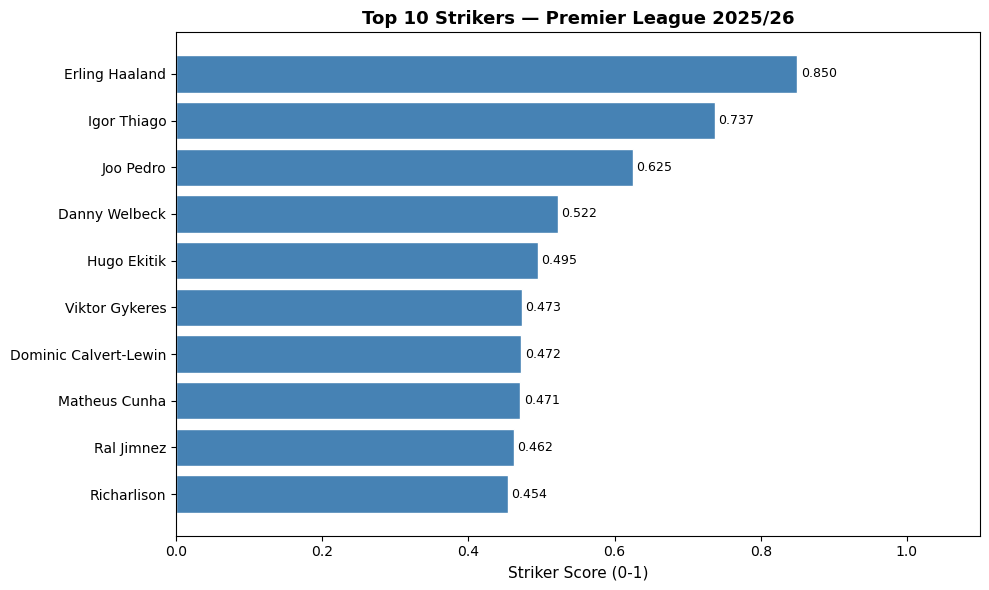

Chart saved as top_strikers.png


In [13]:
# STEP 13: Bar chart — Top 10 Strikers by Score

fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart makes long names easier to read
bars = ax.barh(top_strikers["Player"], top_strikers["Score"],
               color="steelblue", edgecolor="white")

# Add score labels at the end of each bar
for bar, score in zip(bars, top_strikers["Score"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}", va="center", fontsize=9)

# Flip so the best player appears at the top
ax.invert_yaxis()
ax.set_xlabel("Striker Score (0-1)", fontsize=11)
ax.set_title("Top 10 Strikers — Premier League 2025/26", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.savefig("top_strikers.png", dpi=150)
plt.show()
print("Chart saved as top_strikers.png")

## 5. Most Creative Player

In [ ]:
# STEP 14: Find the Most Creative Player
# Creativity is measured for ALL outfield players:
#   key passes (30%)  assists (25%)  big chances created (25%)
#   expected assists xA (10%)  accurate final third passes (10%)

# All outfield players — not goalkeepers
outfield = df[df["position"] != "G"].copy()
outfield = outfield[outfield["appearances"] >= 5]

# Normalise each creativity factor
outfield["norm_keypasses"]  = normalise(outfield["keyPasses"])
outfield["norm_assists"]    = normalise(outfield["assists"])
outfield["norm_bigchances"] = normalise(outfield["bigChancesCreated"])
outfield["norm_xa"]         = normalise(outfield["expectedAssists"])
outfield["norm_finalthird"] = normalise(outfield["accurateFinalThirdPasses"])

# Build the weighted creativity score
outfield["creativity_score"] = (
    outfield["norm_keypasses"]  * 0.30 +
    outfield["norm_assists"]    * 0.25 +
    outfield["norm_bigchances"] * 0.25 +
    outfield["norm_xa"]         * 0.10 +
    outfield["norm_finalthird"] * 0.10
).round(3)

# Select and sort
top_creative = outfield.sort_values("creativity_score", ascending=False)[
    ["player_name", "team_name", "position", "keyPasses",
     "assists", "bigChancesCreated", "expectedAssists", "creativity_score"]
].head(10).reset_index(drop=True)

top_creative.columns = ["Player", "Club", "Pos", "Key Passes","Assists", "Big Chances Created", "xA", "Score"]

print("TOP 10 MOST CREATIVE PLAYERS:")
top_creative

TOP 10 MOST CREATIVE PLAYERS:


,Player,Club,Pos,Key Passes,Assists,Big Chances Created,xA,Score
0,Bruno Fernandes,Manchester United,M,101,16,24,9.076813,0.993
1,Declan Rice,Arsenal,M,59,5,14,6.073121,0.547
2,Rayan Cherki,Manchester City,M,43,8,15,6.620215,0.541
3,James Garner,Everton,M,44,6,11,4.773860,0.462
4,Enzo Fernndez,Chelsea,M,52,3,10,5.972165,0.452
5,Dominik Szoboszlai,Liverpool,M,58,3,7,5.166456,0.449
6,Pedro Neto,Chelsea,M,45,4,11,5.644087,0.434
7,Mohamed Salah,Liverpool,M,44,6,10,4.345298,0.425
8,Bukayo Saka,Arsenal,F,54,3,9,5.761951,0.417
9,Anton Stach,Leeds United,M,58,3,9,4.325190,0.401


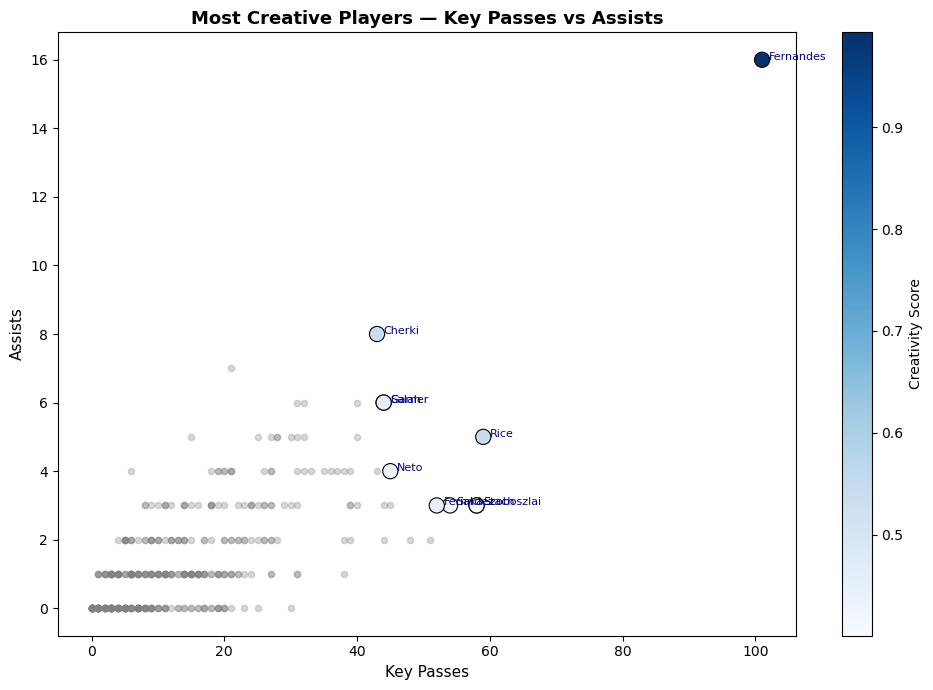

Chart saved as top_creative.png


In [24]:
# STEP 15: Scatter plot — Key Passes vs Assists
# The top 10 most creative players are highlighted in colour.
# Dot colour represents creativity score.

fig, ax = plt.subplots(figsize=(10, 7))

# Background: all outfield players in grey
ax.scatter(outfield["keyPasses"], outfield["assists"],
           alpha=0.3, color="grey", s=20, label="All players")

# Highlight top 10 in colour
top10_names = top_creative["Player"].tolist()
top_data = outfield[outfield["player_name"].isin(top10_names)]

scatter = ax.scatter(top_data["keyPasses"], top_data["assists"],
                     c=top_data["creativity_score"], cmap="Blues",
                     s=120, edgecolors="black", linewidths=0.8, zorder=3)

# Label each highlighted player by surname
for _, row in top_data.iterrows():
    ax.annotate(row["player_name"].split()[-1],
                (row["keyPasses"] + 1, row["assists"]),
                fontsize=8, color="navy")

plt.colorbar(scatter, ax=ax, label="Creativity Score")
ax.set_xlabel("Key Passes", fontsize=11)
ax.set_ylabel("Assists", fontsize=11)
ax.set_title("Most Creative Players — Key Passes vs Assists", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("top_creative.png", dpi=150)
plt.show()
print("Chart saved as top_creative.png")

## 6. Best Defender

In [16]:
# STEP 16: Find the Best Defender
# Scoring weights:
#   tackles won (25%)  interceptions (25%)  clearances (15%)
#   aerial duel win % (15%)  errors leading to goal INVERTED (10%)  rating (10%)

# Filter to defenders only
defenders = df[df["position"] == "D"].copy()
defenders = defenders[defenders["appearances"] >= 5]

# Normalise each defensive metric
defenders["norm_tackles"]       = normalise(defenders["tacklesWon"])
defenders["norm_interceptions"] = normalise(defenders["interceptions"])
defenders["norm_clearances"]    = normalise(defenders["clearances"])
defenders["norm_aerial"]        = normalise(defenders["aerialDuelsWonPercentage"])
defenders["norm_rating"]        = normalise(defenders["rating"])

# Errors leading to goal — fewer = better, so we flip the normalised value
defenders["norm_errors"] = 1 - normalise(defenders["errorLeadToGoal"])

# Build the defensive score
defenders["defender_score"] = (
    defenders["norm_tackles"]       * 0.25 +
    defenders["norm_interceptions"] * 0.25 +
    defenders["norm_clearances"]    * 0.15 +
    defenders["norm_aerial"]        * 0.15 +
    defenders["norm_errors"]        * 0.10 +
    defenders["norm_rating"]        * 0.10
).round(3)

# Select and sort
top_defenders = defenders.sort_values("defender_score", ascending=False)[
    ["player_name", "team_name", "tacklesWon", "interceptions",
     "clearances", "aerialDuelsWonPercentage", "errorLeadToGoal", "rating", "defender_score"]
].head(10).reset_index(drop=True)

top_defenders.columns = ["Player", "Club", "Tackles Won", "Interceptions",
                         "Clearances", "Aerial %", "Errors to Goal", "Rating", "Score"]

print("TOP 10 DEFENDERS:")
top_defenders

TOP 10 DEFENDERS:


,Player,Club,Tackles Won,Interceptions,Clearances,Aerial %,Errors to Goal,Rating,Score
0,Marcos Senesi,Bournemouth,30,47,220,48.684211,0,7.186667,0.790
1,Maxence Lacroix,Crystal Palace,31,35,203,59.615385,0,6.892857,0.708
2,Neco Williams,Nottingham Forest,51,36,72,53.030303,1,6.890000,0.663
3,Marc Guhi,Manchester City,24,39,137,68.907563,1,7.275000,0.661
4,Adrien Truffert,Bournemouth,44,40,123,44.827586,1,6.696774,0.648
5,Nordi Mukiele,Sunderland,38,32,129,63.302752,1,6.976000,0.644
6,Konstantinos Mavropanos,West Ham United,19,37,149,65.882353,0,6.912500,0.639
7,Michael Keane,Everton,20,33,174,62.411348,0,6.973077,0.638
8,Trevoh Chalobah,Chelsea,23,34,165,52.845528,0,6.996552,0.637
9,Ibrahima Konat,Liverpool,25,23,162,71.942446,0,7.103448,0.633


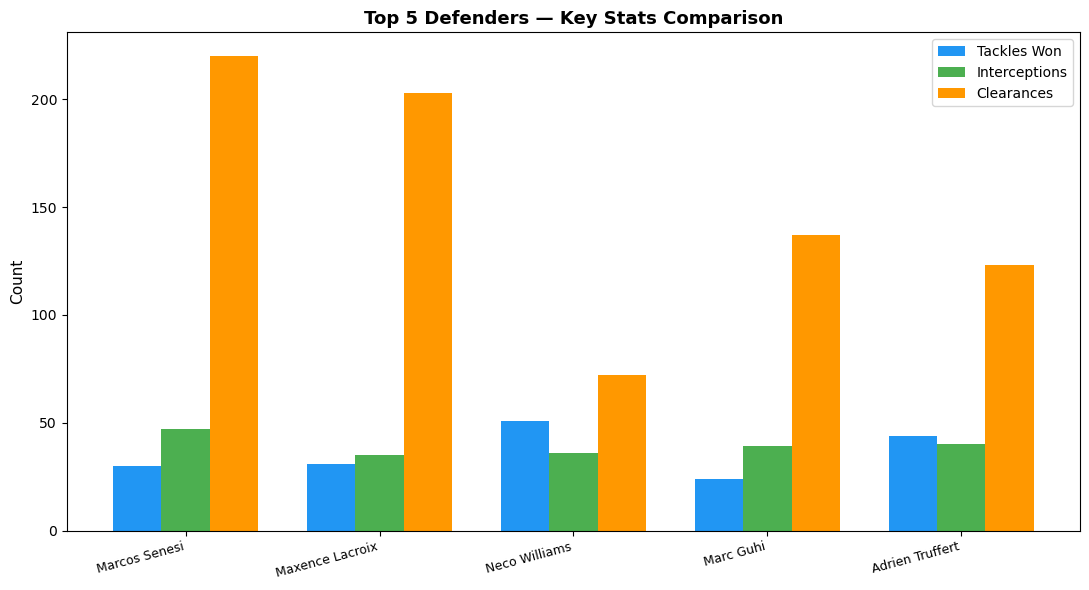

Chart saved as top_defenders.png


In [17]:
# STEP 17: Grouped bar chart comparing top 5 defenders across 3 key stats

top5_def = defenders.sort_values("defender_score", ascending=False).head(5)

fig, ax = plt.subplots(figsize=(11, 6))

# Position groups along the x axis
x = np.arange(len(top5_def))
width = 0.25   # width of each individual bar

# Draw 3 bars per player
ax.bar(x - width, top5_def["tacklesWon"],    width, label="Tackles Won",   color="#2196F3")
ax.bar(x,          top5_def["interceptions"], width, label="Interceptions", color="#4CAF50")
ax.bar(x + width,  top5_def["clearances"],    width, label="Clearances",    color="#FF9800")

ax.set_xticks(x)
ax.set_xticklabels(top5_def["player_name"], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Top 5 Defenders — Key Stats Comparison", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("top_defenders.png", dpi=150)
plt.show()
print("Chart saved as top_defenders.png")

## 7. Best Goalkeeper

In [18]:
# STEP 18: Find the Best Goalkeeper
# Scoring weights:
#   saves (25%)  clean sheets (20%)  goals prevented (20%)
#   save % (15%)  errors INVERTED (10%)  rating (10%)

# Filter to goalkeepers only
keepers = df[df["position"] == "G"].copy()
keepers = keepers[keepers["appearances"] >= 5]

# Calculate save percentage: saves / (saves + goals conceded) * 100
keepers["total_shots_faced"] = keepers["saves"] + keepers["goalsConceded"]

# Use .apply() to compute row by row — safely avoids division by zero
keepers["save_pct"] = keepers.apply(
    lambda row: (row["saves"] / row["total_shots_faced"] * 100)
                if row["total_shots_faced"] > 0 else 0,
    axis=1
)

# Normalise each goalkeeping stat
keepers["norm_saves"]     = normalise(keepers["saves"])
keepers["norm_cs"]        = normalise(keepers["cleanSheet"])
keepers["norm_prevented"] = normalise(keepers["goalsPrevented"])
keepers["norm_save_pct"]  = normalise(keepers["save_pct"])
keepers["norm_rating"]    = normalise(keepers["rating"])
keepers["norm_errors"]    = 1 - normalise(keepers["errorLeadToGoal"])

# Build the goalkeeper score
keepers["gk_score"] = (
    keepers["norm_saves"]     * 0.25 +
    keepers["norm_cs"]        * 0.20 +
    keepers["norm_prevented"] * 0.20 +
    keepers["norm_save_pct"]  * 0.15 +
    keepers["norm_errors"]    * 0.10 +
    keepers["norm_rating"]    * 0.10
).round(3)

# Select and sort
top_keepers = keepers.sort_values("gk_score", ascending=False)[
    ["player_name", "team_name", "saves", "cleanSheet",
     "goalsPrevented", "save_pct", "errorLeadToGoal", "rating", "gk_score"]
].head(10).reset_index(drop=True)

top_keepers.columns = ["Player", "Club", "Saves", "Clean Sheets",
                       "Goals Prevented", "Save %", "Errors to Goal", "Rating", "Score"]
top_keepers["Save %"] = top_keepers["Save %"].round(1)

print("TOP 10 GOALKEEPERS:")
top_keepers

TOP 10 GOALKEEPERS:


,Player,Club,Saves,Clean Sheets,Goals Prevented,Save %,Errors to Goal,Rating,Score
0,Dean Henderson,Crystal Palace,86,10,4.3971,71.1,0,7.058621,0.848
1,Jordan Pickford,Everton,86,11,5.1314,71.1,3,7.093548,0.779
2,Gianluigi Donnarumma,Manchester City,64,11,2.2868,72.7,1,7.014815,0.740
3,Robert Snchez,Chelsea,80,9,2.1411,70.2,1,6.934483,0.726
4,Bart Verbruggen,Brighton &amp; Hove Albion,87,7,1.0935,70.2,2,7.077419,0.681
5,David Raya,Arsenal,50,15,-0.8838,69.4,1,6.929032,0.674
6,Robin Roefs,Sunderland,85,8,0.2134,71.4,2,7.032143,0.674
7,Emiliano Martnez,Aston Villa,76,7,3.2959,72.4,3,6.937037,0.655
8,Senne Lammens,Manchester United,57,5,3.1150,64.0,0,6.932000,0.638
9,?or?e Petrovi?,Bournemouth,94,9,-1.8528,66.2,2,6.906452,0.629


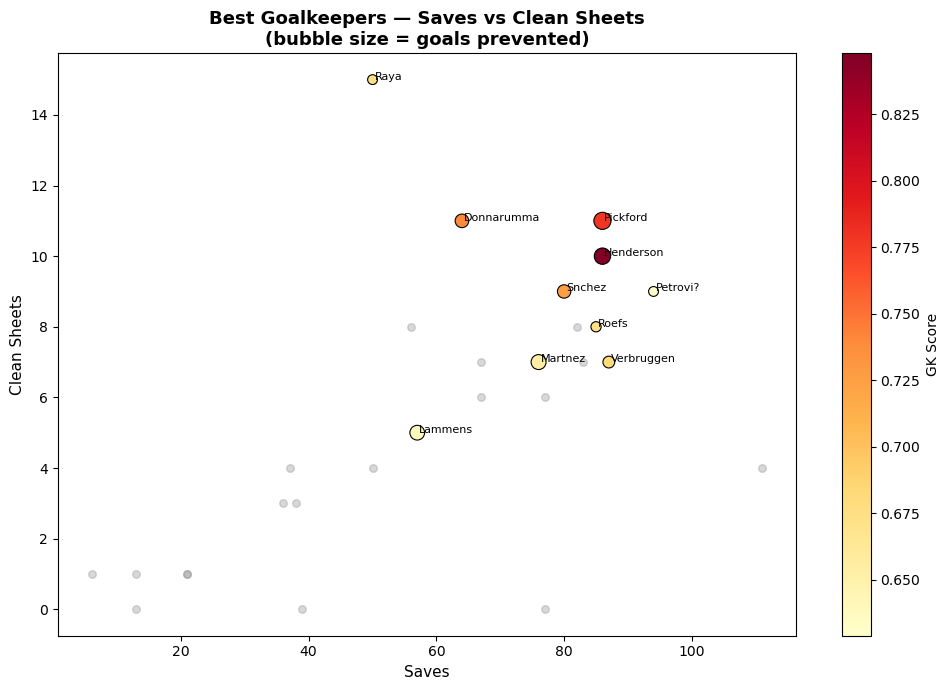

Chart saved as top_keepers.png


In [19]:
# STEP 19: Bubble chart — Saves vs Clean Sheets
# Bubble size represents Goals Prevented — bigger = better shot-stopper

fig, ax = plt.subplots(figsize=(10, 7))

# Background: all keepers in light grey
ax.scatter(keepers["saves"], keepers["cleanSheet"],
           alpha=0.3, color="grey", s=30)

# Highlight top 10 keepers with coloured bubbles
top10_k_names = top_keepers["Player"].tolist()
top_k_data = keepers[keepers["player_name"].isin(top10_k_names)]

# Bubble size based on goals prevented (clip to 0 so no negatives)
bubble_size = top_k_data["goalsPrevented"].clip(lower=0) * 20 + 50

scatter = ax.scatter(top_k_data["saves"], top_k_data["cleanSheet"],
                     s=bubble_size, c=top_k_data["gk_score"],
                     cmap="YlOrRd", edgecolors="black", linewidths=0.8, zorder=3)

# Label each highlighted keeper
for _, row in top_k_data.iterrows():
    ax.annotate(row["player_name"].split()[-1],
                (row["saves"] + 0.3, row["cleanSheet"]),
                fontsize=8)

plt.colorbar(scatter, ax=ax, label="GK Score")
ax.set_xlabel("Saves", fontsize=11)
ax.set_ylabel("Clean Sheets", fontsize=11)
ax.set_title("Best Goalkeepers — Saves vs Clean Sheets\n(bubble size = goals prevented)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("top_keepers.png", dpi=150)
plt.show()
print("Chart saved as top_keepers.png")

## 8. Team Table

In [ ]:
# STEP 20: Build the Team Table
# We group all players by club and aggregate team-level stats:
#   Total goals and assists (attacking output)
#   Average player rating   (team quality)
#   Average touches         (possession proxy)
#   Total saves             (goalkeeping quality)

team_stats = df.groupby("team_name").agg(
    Players       = ("player_name",  "count"),
    Total_Goals   = ("goals",        "sum"),
    Total_Assists = ("assists",      "sum"),
    Avg_Rating    = ("rating",       "mean"),
    Avg_Touches   = ("touches",      "mean"),
    Total_Saves   = ("saves",        "sum"),
).reset_index()

# Round decimal columns
team_stats["Avg_Rating"]  = team_stats["Avg_Rating"].round(2)
team_stats["Avg_Touches"] = team_stats["Avg_Touches"].round(1)

# Normalise for the performance score calculation
team_stats["norm_goals"]   = normalise(team_stats["Total_Goals"])
team_stats["norm_assists"] = normalise(team_stats["Total_Assists"])
team_stats["norm_rating"]  = normalise(team_stats["Avg_Rating"])
team_stats["norm_touches"] = normalise(team_stats["Avg_Touches"])

# Build a weighted performance score
team_stats["Performance_Score"] = (
    team_stats["norm_goals"]   * 0.40 +
    team_stats["norm_assists"] * 0.25 +
    team_stats["norm_rating"]  * 0.25 +
    team_stats["norm_touches"] * 0.10
).round(3)

# Drop the temporary normalised columns — they were only for the calculation
team_stats = team_stats.drop(columns=["norm_goals", "norm_assists",
                                       "norm_rating", "norm_touches"])

# Sort best team first
team_stats = team_stats.sort_values("Performance_Score", ascending=False).reset_index(drop=True)

# Add a rank column
team_stats.insert(0, "Rank", range(1, len(team_stats) + 1))

team_stats.columns = ["Rank", "Club", "Players", "Goals", "Assists","Avg Rating", "Avg Touches", "Total Saves", "Perf. Score"]

print("TEAM TABLE:")
team_stats

TEAM TABLE:


,Rank,Club,Players,Goals,Assists,Avg Rating,Avg Touches,Total Saves,Perf. Score
0,1,Manchester City,26,69,50,6.97,972.7,75,0.987
1,2,Arsenal,24,57,43,6.89,852.9,50,0.767
2,3,Chelsea,24,52,35,6.81,946.5,86,0.647
3,4,Liverpool,22,48,32,6.79,1033.1,77,0.601
4,5,Manchester United,27,53,38,6.55,761.6,70,0.504
5,6,Brentford,23,45,29,6.73,791.1,83,0.470
6,7,Fulham,23,39,26,6.78,906.5,77,0.448
7,8,Everton,22,35,28,6.82,825.1,86,0.431
8,9,Aston Villa,29,40,28,6.76,681.0,89,0.411
9,10,Brighton &amp; Hove Albion,27,40,24,6.75,762.3,87,0.395


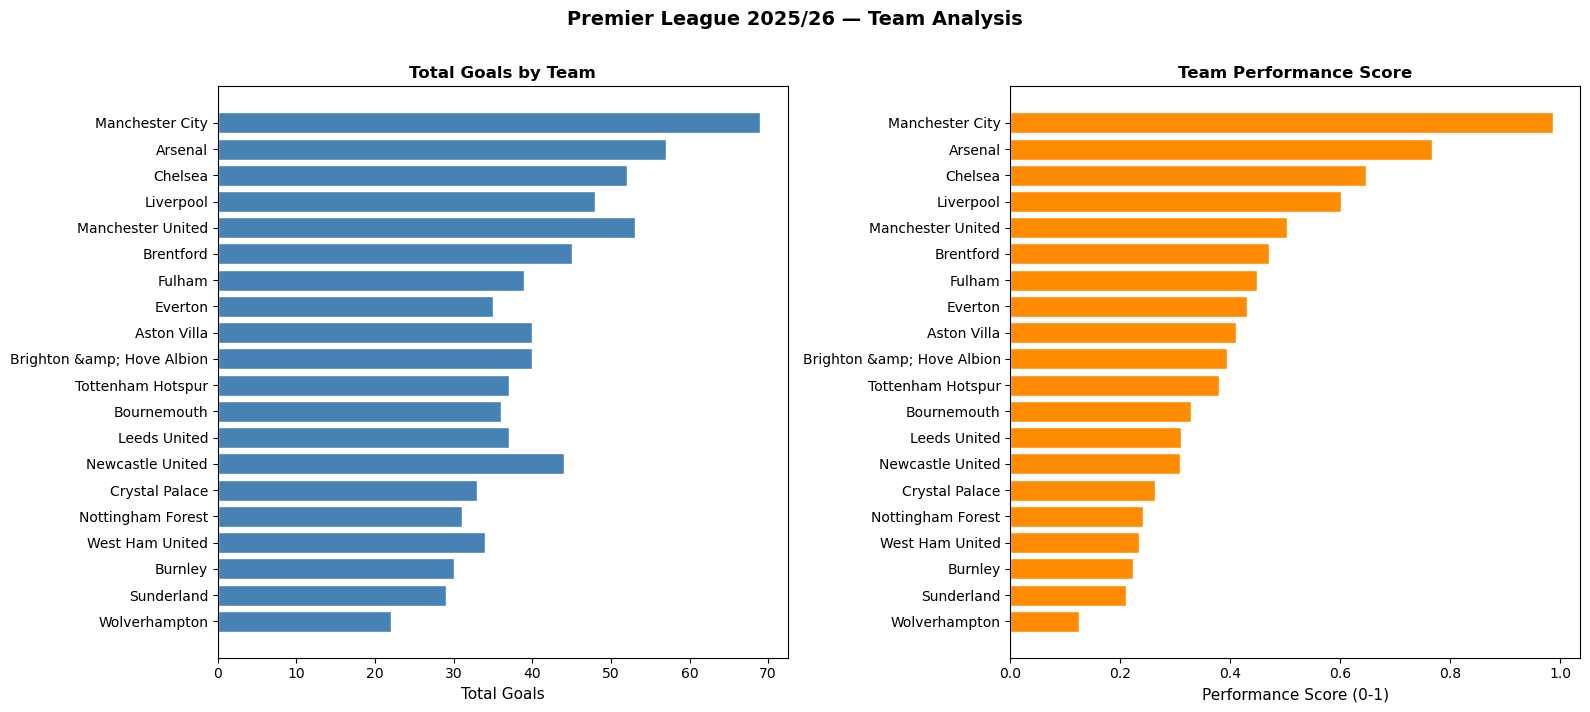

Chart saved as team_table.png


In [21]:
# STEP 21: Side-by-side bar charts — Team Goals and Performance Score

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left chart: Total Goals per team
axes[0].barh(team_stats["Club"], team_stats["Goals"],
             color="steelblue", edgecolor="white")
axes[0].invert_yaxis()   # Best team at the top
axes[0].set_xlabel("Total Goals", fontsize=11)
axes[0].set_title("Total Goals by Team", fontsize=12, fontweight="bold")

# Right chart: Performance Score per team
axes[1].barh(team_stats["Club"], team_stats["Perf. Score"],
             color="darkorange", edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_xlabel("Performance Score (0-1)", fontsize=11)
axes[1].set_title("Team Performance Score", fontsize=12, fontweight="bold")

plt.suptitle("Premier League 2025/26 — Team Analysis",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("team_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as team_table.png")

## 9. Player Search — Interactive Profile Viewer

In [22]:
# STEP 22: Define player search and profile display functions

def find_player(df, search_term):
    """
    Searches for players whose name CONTAINS the search_term.
    The search ignores uppercase/lowercase differences.
    """
    # Convert both name and search term to lowercase before comparing
    mask = df["player_name"].str.lower().str.contains(search_term.lower(), na=False)
    return df[mask].reset_index(drop=True)


def show_player_profile(player_row, conn):
    """
    Prints a detailed profile for a single player.
    Also pulls their record from the SQLite database.
    """
    name = player_row["player_name"]

    print("\n" + "=" * 55)
    print(f"  PLAYER PROFILE: {name.upper()}")
    print("=" * 55)

    # Basic info
    print(f"  Club        : {player_row['team_name']}")
    print(f"  Position    : {player_row['position']}")
    print(f"  Appearances : {player_row['appearances']}")
    print(f"  Minutes     : {player_row['minutesPlayed']}")
    print(f"  Rating      : {player_row['rating']:.2f}")

    # Attacking stats — shown for forwards and midfielders
    if player_row["position"] in ["F", "M"]:
        print("\n  ATTACKING:")
        print(f"  Goals           : {player_row['goals']}")
        print(f"  Assists         : {player_row['assists']}")
        print(f"  xG              : {player_row['expectedGoals']:.2f}")
        print(f"  xA              : {player_row['expectedAssists']:.2f}")
        print(f"  Key Passes      : {player_row['keyPasses']}")
        print(f"  Chances Created : {player_row['bigChancesCreated']}")
        print(f"  Shots on Target : {player_row['shotsOnTarget']}")

    # Defensive stats — shown for defenders and midfielders
    if player_row["position"] in ["D", "M"]:
        print("\n  DEFENSIVE:")
        print(f"  Tackles Won    : {player_row['tacklesWon']}")
        print(f"  Interceptions  : {player_row['interceptions']}")
        print(f"  Clearances     : {player_row['clearances']}")
        print(f"  Aerial Won %   : {player_row['aerialDuelsWonPercentage']:.1f}%")

    # Goalkeeping stats
    if player_row["position"] == "G":
        print("\n  GOALKEEPING:")
        print(f"  Saves           : {player_row['saves']}")
        print(f"  Clean Sheets    : {player_row['cleanSheet']}")
        print(f"  Goals Prevented : {player_row['goalsPrevented']}")
        print(f"  Goals Conceded  : {player_row['goalsConceded']}")

    # Discipline
    print("\n  DISCIPLINE:")
    print(f"  Yellow Cards : {player_row['yellowCards']}")
    print(f"  Red Cards    : {player_row['redCards']}")
    print(f"  Fouls        : {player_row['fouls']}")
    print(f"  Was Fouled   : {player_row['wasFouled']}")

    # Pull the player's record from the database
    print("\n  DATABASE RECORD:")
    cursor = conn.cursor()
    cursor.execute(
        "SELECT * FROM player WHERE player_name LIKE ?", (f"%{name}%",)
    )
    db_row = cursor.fetchone()

    if db_row:
        print(f"  DB ID          : {db_row[0]}")
        print(f"  Preferred Foot : {db_row[3]}")
        print(f"  Matches (DB)   : {db_row[5]}")
        print(f"  Minutes (DB)   : {db_row[6]}")
        print(f"  Rating (DB)    : {db_row[7]:.3f}")
    else:
        print(f"  (No database record found for {name})")

    print("=" * 55 + "\n")


# ─── Run the interactive search ─────────────────────────────────────────
search_term = input("Enter a player name (or part of it): ").strip()

if search_term == "":
    print("Please enter at least one character.")
else:
    matches = find_player(df, search_term)

    if matches.empty:
        print(f"No players found matching '{search_term}'.")

    elif len(matches) == 1:
        # Only one match — show it straight away
        show_player_profile(matches.iloc[0], conn)

    else:
        # Multiple matches — let the user pick the right one
        print(f"\nFound {len(matches)} players matching '{search_term}':\n")
        for i, row in matches.iterrows():
            print(f"  [{i + 1}] {row['player_name']} — {row['team_name']} ({row['position']})")

        pick = input("\nEnter the number of the player you want: ").strip()

        if pick.isdigit() and 1 <= int(pick) <= len(matches):
            show_player_profile(matches.iloc[int(pick) - 1], conn)
        else:
            print("Invalid selection.")

Please enter at least one character.
